# 2-D Combination in Compactness-Mass space

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, multivariate_normal, norm
from scipy.special import logsumexp
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg
floor = 1e-300

In [ ]:
# load data
MODELS = {
    "ST_PST19": dict(file="../datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="../datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra24: ST+PDT"),
    "ST_PST":   dict(file="../datafiles/ST_PST",   color="tab:orange", label="Vinciguerra24: ST+PST"),
    "PDT_U":    dict(file="../datafiles/PDT_U",    color="tab:green",  label="Vinciguerra24: PDT--U"),
    "ST_U":     dict(file="../datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra24: ST--U"),
    "2spot":    dict(file="../datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="../datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="../datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
}

# Grid resolutions
nC = 80
nM = 80
C_grid = np.linspace(0.05, 0.35, nC)    # compactness grid
M_grid = np.linspace(1.0, 2.2, nM)      # mass grid (Msun)
dC = C_grid[1] - C_grid[0]
dM = M_grid[1] - M_grid[0]
CC, MM = np.meshgrid(C_grid, M_grid, indexing='ij')
points = np.vstack([CC.ravel(), MM.ravel()])

In [ ]:
def normalize_pdf2d(pdf, dC, dM):
    pdf = np.asarray(pdf, dtype=float)
    pdf = np.nan_to_num(pdf, nan=0.0, posinf=0.0, neginf=0.0)
    pdf = np.maximum(pdf, 0.0)
    s = np.sum(pdf) * dC * dM
    if not np.isfinite(s) or s <= 0:
        total = np.sum(pdf)
        if np.isfinite(total) and total > 0:
            return pdf / total
        return np.ones_like(pdf, dtype=float) / pdf.size
    return pdf / s

# Build 2-D KDEs for each model from (M,R) files by converting to (C,M)
KDEs_2D = {}
logKDEs_2D = {}
mu_i = {}
Sigma_B_i = {}
q_dict = {}

for key, meta in MODELS.items():
    filename = meta['file']
    data = np.loadtxt(filename)
    M_samples, R_samples = data.T[0], data.T[1]
    M_si = M_samples * M_sun
    R_si = R_samples * 1e3
    C_samples = G * M_si / (R_si * c**2)

    # Build KDE in 2D: order (C, M)
    X_i = np.vstack([C_samples, M_samples])
    kde_i = gaussian_kde(X_i, bw_method='silverman')
    q_i = kde_i(points).reshape(nC, nM)

    # store
    KDEs_2D[key] = kde_i
    q_dict[key] = normalize_pdf2d(q_i, dC, dM)
    logKDEs_2D[key] = np.log(q_dict[key] + floor)
    mu_i[key] = np.array([np.median(C_samples), np.median(M_samples)])
    Sigma_B_i[key] = np.cov(np.vstack([C_samples, M_samples]), bias=False)
    print(f"{meta['label']}: mu={mu_i[key]}, Sigma_B eigs={np.linalg.eigvals(Sigma_B_i[key])}")
    
    

Riley19: ST+PST: mu=[0.15326728 1.28862368], Sigma_B eigs=[9.9150443e-05 2.5120247e-02]
Vinciguerra24: ST+PDT: mu=[0.17728821 1.3952278 ], Sigma_B eigs=[3.69073957e-05 1.52683828e-02]
Vinciguerra24: ST+PST: mu=[0.18798464 1.92718634], Sigma_B eigs=[2.61733957e-05 1.52159694e-02]
Vinciguerra24: PDT--U: mu=[0.17911947 1.70174259], Sigma_B eigs=[0.00010139 0.03448135]
Vinciguerra24: ST--U: mu=[0.18611724 1.88334256], Sigma_B eigs=[4.71565311e-05 3.33337733e-02]
Miller19: 2spot: mu=[0.16033259 1.442495  ], Sigma_B eigs=[4.46239580e-05 2.78151638e-02]
Miller19: 3spot: mu=[0.16310562 1.440159  ], Sigma_B eigs=[5.56591622e-05 2.23496132e-02]
Kini26: PDT--U: mu=[0.1689488  1.43454387], Sigma_B eigs=[8.49275014e-05 3.61575245e-02]


In [ ]:
# hyperparameter grids (keep sizes modest)
sigma_grid = np.logspace(-4, -0.5, 8)
alpha_grid = np.linspace(1.0, 5.0, 8)
p_grid = np.linspace(0.0, 1.0, 25)
rho_grid = np.linspace(0.0, 1.0, 9)

prior_rho = np.ones_like(rho_grid) / (rho_grid.size)

prior_sigma = normalize_pdf2d(1.0 / sigma_grid, 1.0, 1.0)  # placeholder normalization (1D)
prior_p = np.ones_like(p_grid) / (p_grid.size)

prior_alpha = np.exp(-alpha_grid)
prior_alpha = prior_alpha / np.trapz(prior_alpha, alpha_grid)

#### Build 2-D bad/systematic likelihoods for each model
We marginalize over small shifts Delta (2-D) and over alpha scaling of the model covariance.

In [ ]:
def build_bad_likelihoods_2d(model_keys, mu_i, Sigma_B_i, CC, MM, points, sigma_grid, alpha_grid, prior_alpha, floor):
    b_dict = {}
    nC, nM = CC.shape
    grid_shape = (nC, nM)

    for key in model_keys:
        mu = mu_i[key]
        SigmaB = Sigma_B_i[key].copy()
        b_sigma = []

        for sigma in sigma_grid:
            # construct delta grid in 2D (independent in C and M)
            if np.isclose(sigma, 0.0):
                delta_pairs = np.array([[0.0, 0.0]])
                prior_delta = np.array([1.0])
            else:
                n_d = 13
                dC_shift = np.linspace(-4*sigma, 4*sigma, n_d)
                dM_shift = np.linspace(-4*sigma, 4*sigma, n_d)
                DC, DM = np.meshgrid(dC_shift, dM_shift, indexing='ij')
                delta_pairs = np.vstack([DC.ravel(), DM.ravel()]).T
                prior_delta = norm.pdf(DC.ravel(), loc=0, scale=sigma) * norm.pdf(DM.ravel(), loc=0, scale=sigma)
                prior_delta = prior_delta / np.sum(prior_delta)

            b_alpha = []
            for alpha in alpha_grid:
                cov = (alpha**2) * SigmaB
                # evaluate multivariate normal centered at mu + delta for each delta
                # this yields (n_delta, nC*nM) array; we'll marginalize over delta with prior_delta
                n_delta = delta_pairs.shape[0]
                evals = np.zeros((n_delta, CC.size))
                for j, d in enumerate(delta_pairs):
                    rv = multivariate_normal(mean=mu + d, cov=cov + 1e-12*np.eye(2))
                    evals[j] = rv.pdf(points.T)
                # marginalize over delta
                b_delta_marg = np.dot(prior_delta, evals).reshape(grid_shape)
                b_delta_marg = normalize_pdf2d(b_delta_marg, dC, dM)
                b_alpha.append(b_delta_marg)

            b_alpha = np.array(b_alpha)
            b_marg = np.trapz(b_alpha * prior_alpha[:, None, None], alpha_grid, axis=0)
            b_marg = normalize_pdf2d(b_marg, dC, dM)
            b_sigma.append(b_marg)

        b_dict[key] = np.array(b_sigma)
    return b_dict

# build bad likelihoods for model keys
b_dict = build_bad_likelihoods_2d(list(MODELS.keys()), mu_i, Sigma_B_i, CC, MM, points, sigma_grid, alpha_grid, prior_alpha, floor)

print('Good KDE normalization diagnostics:')
for key in q_dict:
    total = np.sum(q_dict[key]) * dC * dM
    print(f'  {key}: mass={total:.3e}, min={np.min(q_dict[key]):.3e}, max={np.max(q_dict[key]):.3e}, n_nan={np.isnan(q_dict[key]).sum()}')
print('Bad likelihood build complete.')
print('Bad likelihood normalization diagnostics:')
for key in b_dict:
    for s_idx in range(min(2, b_dict[key].shape[0])):
        total = np.sum(b_dict[key][s_idx]) * dC * dM
        print(f'  {key} sigma[{s_idx}]: mass={total:.3e}, min={np.min(b_dict[key][s_idx]):.3e}, max={np.max(b_dict[key][s_idx]):.3e}, n_nan={np.isnan(b_dict[key][s_idx]).sum()}')

Good KDE normalization diagnostics:
  ST_PST19: mass=1.000e+00, min=0.000e+00, max=9.013e+01, n_nan=0
  ST_PDT: mass=1.000e+00, min=0.000e+00, max=2.364e+02, n_nan=0
  ST_PST: mass=1.000e+00, min=0.000e+00, max=3.118e+02, n_nan=0
  PDT_U: mass=1.000e+00, min=0.000e+00, max=9.410e+01, n_nan=0
  ST_U: mass=1.000e+00, min=0.000e+00, max=2.311e+02, n_nan=0
  2spot: mass=1.000e+00, min=0.000e+00, max=1.458e+02, n_nan=0
  3spot: mass=1.000e+00, min=0.000e+00, max=1.589e+02, n_nan=0
  PDT_U26: mass=1.000e+00, min=0.000e+00, max=1.111e+02, n_nan=0
Bad likelihood build complete.
Bad likelihood normalization diagnostics:
  ST_PST19 sigma[0]: mass=1.000e+00, min=7.982e-06, max=5.236e+01, n_nan=0
  ST_PST19 sigma[1]: mass=1.000e+00, min=7.985e-06, max=5.235e+01, n_nan=0
  ST_PDT sigma[0]: mass=1.000e+00, min=4.099e-10, max=1.005e+02, n_nan=0
  ST_PDT sigma[1]: mass=1.000e+00, min=4.106e-10, max=1.004e+02, n_nan=0
  ST_PST sigma[0]: mass=1.000e+00, min=3.861e-14, max=1.247e+02, n_nan=0
  ST_PST sig

#### Divide into groups and build group-pooled likelihoods (log-space mixtures)

In [33]:
GROUPS = {
    "Riley": ["ST_PST19"],
    "Miller": ["2spot", "3spot"],
    "Vinciguerra": ["ST_PST", "ST_U", "ST_PDT", "PDT_U"],
    "Kini": ["PDT_U26"],
}
GROUP_MODELS = list(GROUPS.keys())
model_to_index = {key: i for i, key in enumerate(MODELS)}

# Precompute arrays for g (good) PDFs on grid
g_dict = {k: q_dict[k] for k in q_dict}

group_pool = {g: np.zeros((len(sigma_grid), len(rho_grid), nC, nM)) for g in GROUPS}
g_group_stack = []
mu_group = {}
Sigma_group = {}

for group_name, group_models in GROUPS.items():
    group_indices = [list(MODELS.keys()).index(m) for m in group_models]
    Ng = len(group_models)

    for s_index, sigma in enumerate(sigma_grid):
        # build b_group for this sigma: shape (Ng, nC, nM)
        b_group = np.array([b_dict[m][s_index] for m in group_models])
        g_group = np.array([g_dict[m] for m in group_models])

        # mixture for each model: shape (Ng, nP) where nP=nC*nM; do operations on flattened grid
        b_flat = b_group.reshape(Ng, -1)
        g_flat = g_group.reshape(Ng, -1)

        for r_index, rho_g in enumerate(rho_grid):
            kappa_g = 1.0 / (1.0 + rho_g * (Ng - 1))
            # for each model, compute log mixture over p grid and marginalize p
            logL_models = np.zeros((Ng, p_grid.size, g_flat.shape[1]))
            log_p = np.log(p_grid + floor)[:, None]
            log_1mp = np.log(1.0 - p_grid + floor)[:, None]
            for i_model in range(Ng):
                # evaluate log mixture for each p on flattened grid
                logg = np.log(g_flat[i_model] + floor)[None, :]
                logb = np.log(b_flat[i_model] + floor)[None, :]
                logmix = logsumexp(np.stack([log_p + logg, log_1mp + logb]), axis=0)
                logL_models[i_model] = logmix
            # sum over models and temper by kappa_g
            logL_p = kappa_g * np.sum(logL_models, axis=0)
            # marginalize over p: integrate in linear space with trapz
            L_p = np.exp(logL_p - np.max(logL_p, axis=0, keepdims=True))
            L_C = np.trapz(L_p * prior_p[:, None], p_grid, axis=0)
            L_C = L_C.reshape(nC, nM)
            L_C = normalize_pdf2d(L_C, dC, dM)
            group_pool[group_name][s_index, r_index] = L_C
    # reference good component (s=0,r=0)
    q_group = group_pool[group_name][0, 0].copy()
    q_group = normalize_pdf2d(q_group, dC, dM)
    g_group_stack.append(q_group)
    # compute median and covariance from q_group as effective measurement
    # approximate by sampling from q_group for moment estimates
    flat = q_group.ravel()
    flat /= np.sum(flat)
    n_draw = 5000
    idx = np.random.choice(flat.size, size=n_draw, p=flat)
    Cs = CC.ravel()[idx]
    Ms = MM.ravel()[idx]
    mu_group[group_name] = np.array([np.median(Cs), np.median(Ms)])
    Sigma_group[group_name] = np.cov(np.vstack([Cs, Ms]))

g_group_stack = np.array(g_group_stack)
log_g_group_stack = np.log(g_group_stack + floor)

#### Final marginalization over sigma, rho and systematic convolution

In [34]:
# Prepare b_dict and log_b for group-level models (using mu_group and Sigma_group)
# Rebuild b_dict for group-level 'models' using the same builder but with group stats
group_b_dict = build_bad_likelihoods_2d(GROUP_MODELS, mu_group, Sigma_group, CC, MM, points, sigma_grid, alpha_grid, prior_alpha, floor)

## 2-Dimensional Combination (C, M) — Grouped good/bad + systematics

This notebook is a 2-D rewrite of the 1-D compactness combination. It follows the same hierarchy: individual measurements → group combinations → group-level good/bad mixtures → correlation tempering (rho) → systematic convolution → final posterior.
Notes: uses a common (C,M) grid and multivariate Gaussians for bad/systematic components; KDEs for the measured (C,M).

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, multivariate_normal, norm
from scipy.special import logsumexp
from scipy.signal import fftconvolve
import time

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg
floor = 1e-300

# input models with M--R data (same as original notebook relative paths)
MODELS = {
    "ST_PST19": dict(file="../datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="../datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra24: ST+PDT"),
    "ST_PST":   dict(file="../datafiles/ST_PST",   color="tab:orange", label="Vinciguerra24: ST+PST"),
    "PDT_U":    dict(file="../datafiles/PDT_U",    color="tab:green",  label="Vinciguerra24: PDT--U"),
    "ST_U":     dict(file="../datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra24: ST--U"),
    "2spot":    dict(file="../datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="../datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="../datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
}

# Load data and build 2-D KDEs on a common (C, M) grid
KDEs_2D = {}
logq = {}
mu = {}
Sigma_B = {}
C_samples_dict = {}
M_samples_dict = {}

C_all = []
M_all = []
for key, meta in MODELS.items():
    filename = meta['file']
    data = np.loadtxt(filename)
    M_raw, R_raw = data.T[0], data.T[1]

    # Convert units – keep M in solar masses for combination, R in km
    M = M_raw.copy()
    R = R_raw.copy()

    # Compactness C = GM/(Rc^2) ; R in km -> m
    M_si = M * M_sun
    R_si = R * 1e3
    C = G * M_si / (R_si * c**2)

    # store samples (C dimensionless, M in solar masses)
    C_samples_dict[key] = C
    M_samples_dict[key] = M
    C_all.append(C)
    M_all.append(M)

    # summary statistics (for group-level initialization later)
    mu[key] = np.array([np.median(C), np.median(M)])
    Sigma_B[key] = np.cov(np.vstack([C, M]))

# Global ranges for grid
C_min = min(np.min(a) for a in C_all) * 0.975
C_max = max(np.max(a) for a in C_all) * 1.025
M_min = min(np.min(a) for a in M_all) * 0.975
M_max = max(np.max(a) for a in M_all) * 1.025

# Grid resolution — reduce if too slow
nC = 120
nM = 120
C_grid = np.linspace(C_min, C_max, nC)
M_grid = np.linspace(M_min, M_max, nM)
dC = C_grid[1] - C_grid[0]
dM = M_grid[1] - M_grid[0]

CC, MM = np.meshgrid(C_grid, M_grid, indexing='ij')
points = np.vstack([CC.ravel(), MM.ravel()])

def normalize_pdf_2d(pdf, C_grid, M_grid):
    pdf = np.asarray(pdf, dtype=float)
    pdf = np.nan_to_num(pdf, nan=0.0, posinf=0.0, neginf=0.0)
    pdf = np.maximum(pdf, 0.0)
    dC = C_grid[1] - C_grid[0]
    dM = M_grid[1] - M_grid[0]
    s = np.sum(pdf) * dC * dM
    if not np.isfinite(s) or s <= 0:
        total = np.sum(pdf)
        if np.isfinite(total) and total > 0:
            return pdf / total
        return np.ones_like(pdf, dtype=float) / pdf.size
    return pdf / s

# Build KDEs evaluated on grid
for key in MODELS.keys():
    C_samps = C_samples_dict[key]
    M_samps = M_samples_dict[key]
    X = np.vstack([C_samps, M_samps])
    kde = gaussian_kde(X)
    q = kde(points).reshape(nC, nM)
    q = normalize_pdf_2d(q, C_grid, M_grid)
    KDEs_2D[key] = q
    logq[key] = np.log(q + floor)

# stack for ease of selection (preserve order of MODELS keys)

model_keys = list(MODELS.keys())

g_stack = np.array([KDEs_2D[k] for k in model_keys])
print('Built 2-D KDEs on grid', CC.shape)
log_g_stack = np.array([logq[k] for k in model_keys])

Built 2-D KDEs on grid (120, 120)


DIAG KDE_ST_PST19: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.0, max=89.63950868701154
DIAG logq_ST_PST19: shape=(120, 120), n_nan=0, n_inf=0, sum=-1.43389e+06, min=-690.7755278982137, max=4.495796167960672
DIAG KDE_ST_PDT: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.0, max=243.07146636914956
DIAG logq_ST_PDT: shape=(120, 120), n_nan=0, n_inf=0, sum=-3.5123e+06, min=-690.7755278982137, max=5.493355500386103
DIAG KDE_ST_PST: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.0, max=314.82482166295125
DIAG logq_ST_PST: shape=(120, 120), n_nan=0, n_inf=0, sum=-3.74619e+06, min=-690.7755278982137, max=5.752016362427686
DIAG KDE_PDT_U: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.0, max=94.10245932289234
DIAG logq_PDT_U: shape=(120, 120), n_nan=0, n_inf=0, sum=-1.94402e+06, min=-690.7755278982137, max=4.544384181455897


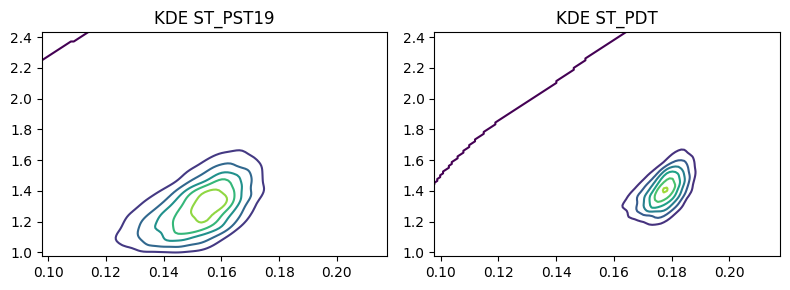

KDE diagnostics complete


In [38]:
# Diagnostic helpers: shapes, NaN/Inf counts, quick contour plots for KDEs
import matplotlib.pyplot as plt

def diag(name, a):
    a = np.asarray(a)
    print(f"DIAG {name}: shape={a.shape}, n_nan={np.isnan(a).sum()}, n_inf={np.isinf(a).sum()}, sum={np.nansum(a):.6g}, min={np.nanmin(a) if np.any(np.isfinite(a)) else np.nan}, max={np.nanmax(a) if np.any(np.isfinite(a)) else np.nan}")

# Run basic diagnostics on KDEs and logq
for i, k in enumerate(model_keys[:4]):
    diag(f'KDE_{k}', KDEs_2D[k])
    diag(f'logq_{k}', logq[k])

# Quick visual checks for first two KDEs
plt.figure(figsize=(8,3))
for i, k in enumerate(model_keys[:2]):
    plt.subplot(1,2,i+1)
    plt.contour(C_grid, M_grid, KDEs_2D[k].T, levels=6)
    plt.title(f'KDE {k}')
plt.tight_layout()
plt.show()

print('KDE diagnostics complete')


#### priors and parameter grids (kept similar to 1-D)

In [39]:
sigma_grid = np.logspace(-4, -0.5, 8)  # systematic width (applied to both dims via isotropic term)
prior_sigma = (1.0 / sigma_grid) / np.trapz(1.0 / sigma_grid, sigma_grid)

alpha_grid = np.linspace(1.0, 5.0, 8)
prior_alpha = np.exp(-alpha_grid)
prior_alpha /= np.trapz(prior_alpha, alpha_grid)

p_grid = np.linspace(0.0, 1.0, 30)[1:-1]  # avoid endpoints exactly 0/1
prior_p = np.ones_like(p_grid)
prior_p = prior_p / np.trapz(prior_p, p_grid)

rho_grid = np.linspace(0.0, 1.0, 11)
prior_rho = np.ones_like(rho_grid)
prior_rho = prior_rho / np.trapz(prior_rho, rho_grid)


#### Build bad/systematic likelihoods for each model in 2-D
(We analytically marginalize the Delta shift by absorbing a small isotropic sigma term into covariance).

In [40]:
def build_bad_likelihoods_2d(model_keys, mu_dict, Sigma_dict, C_grid, M_grid, sigma_grid, alpha_grid, prior_alpha):
    nC = len(C_grid)
    nM = len(M_grid)
    points = np.vstack([np.meshgrid(C_grid, M_grid, indexing='ij')[0].ravel(), np.meshgrid(C_grid, M_grid, indexing='ij')[1].ravel()])
    b_dict = {}
    for key in model_keys:
        SigmaB = Sigma_dict[key]
        mu_k = mu_dict[key]
        b_sigma = []
        for sigma in sigma_grid:
            # Instead of sampling Delta explicitly, incorporate isotropic delta prior with variance sigma^2 I
            b_alpha = []
            for alpha in alpha_grid:
                cov = (alpha**2) * SigmaB + (sigma**2) * np.eye(2)
                rv = multivariate_normal(mean=mu_k, cov=cov, allow_singular=True)
                pdf = rv.pdf(points.T).reshape(nC, nM)
                pdf = normalize_pdf_2d(pdf, C_grid, M_grid)
                b_alpha.append(pdf)
            b_alpha = np.array(b_alpha)
            # marginalize over alpha
            b_marg = np.trapz(b_alpha * prior_alpha[:, None, None], alpha_grid, axis=0)
            b_marg = normalize_pdf_2d(b_marg, C_grid, M_grid)
            b_sigma.append(b_marg)
        b_dict[key] = np.array(b_sigma)  # shape (len(sigma_grid), nC, nM)
    return b_dict

b_dict = build_bad_likelihoods_2d(model_keys, mu, Sigma_B, C_grid, M_grid, sigma_grid, alpha_grid, prior_alpha)
log_b_dict = {k: np.log(np.maximum(b_dict[k], floor)) for k in b_dict}

print('Built bad (systematic) components for each model')


Built bad (systematic) components for each model


Running diagnostics on bad likelihoods (b_dict)
model=ST_PST19, b_dict.shape=(8, 120, 120)
DIAG b_ST_PST19_sigma0: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.007343739650292308, max=51.922610163331726
DIAG b_ST_PST19_sigma1: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.007344825460221782, max=51.90611143866886
DIAG b_ST_PST19_sigma2: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.00735568899647911, max=51.742198039506654


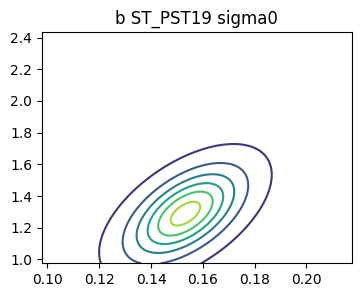

model=ST_PDT, b_dict.shape=(8, 120, 120)
DIAG b_ST_PDT_sigma0: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=2.0854089823007946e-05, max=102.54624187543901
DIAG b_ST_PDT_sigma1: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=2.0870757978503556e-05, max=102.45627664303751
DIAG b_ST_PDT_sigma2: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=2.1038034702164615e-05, max=101.57224420815119


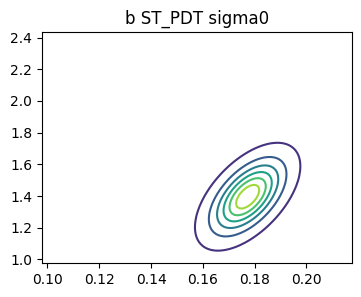

model=ST_PST, b_dict.shape=(8, 120, 120)
DIAG b_ST_PST_sigma0: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=1.7903170656295496e-05, max=120.99311697703354
DIAG b_ST_PST_sigma1: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=1.792694873290468e-05, max=120.84344151935144
DIAG b_ST_PST_sigma2: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=1.8166212169879358e-05, max=119.38305013505469


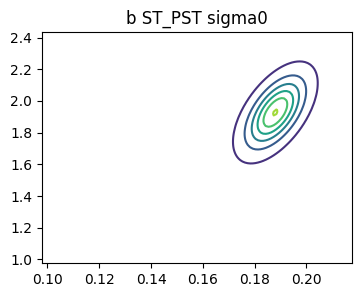

model=PDT_U, b_dict.shape=(8, 120, 120)
DIAG b_PDT_U_sigma0: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.0027333189955698767, max=43.49357248210989
DIAG b_PDT_U_sigma1: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.002733899034285664, max=43.480570621685956
DIAG b_PDT_U_sigma2: shape=(120, 120), n_nan=0, n_inf=0, sum=81166, min=0.002739704928613032, max=43.351394927602016


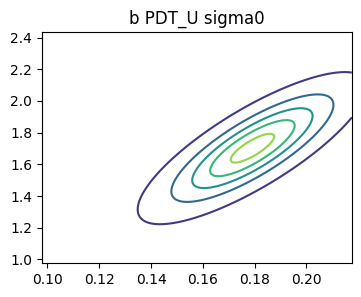

Bad likelihood diagnostics complete


In [41]:
# Diagnostics after building bad/systematic components
print('Running diagnostics on bad likelihoods (b_dict)')
for i, k in enumerate(model_keys[:4]):
    b = b_dict[k]
    print(f'model={k}, b_dict.shape={b.shape}')
    for s_idx in range(min(3, b.shape[0])):
        diag(f'b_{k}_sigma{s_idx}', b[s_idx])
    # quick plot for first sigma
    plt.figure(figsize=(4,3))
    plt.contour(C_grid, M_grid, b[0].T, levels=6)
    plt.title(f'b {k} sigma0')
    plt.show()
print('Bad likelihood diagnostics complete')


#### Divide into groups (same grouping as 1-D) and form group-pooled likelihoods

In [42]:
GROUPS = {
    'Riley': ['ST_PST19'],
    'Miller': ['2spot', '3spot'],
    'Vinciguerra': ['ST_PST', 'ST_U', 'ST_PDT', 'PDT_U'],
    'Kini': ['PDT_U26'],
}
GROUP_MODELS = list(GROUPS.keys())
model_to_index = {key: i for i, key in enumerate(model_keys)}

NC = len(C_grid)
NM = len(M_grid)

# Precompute log quantities for models across sigma
log_b_stack_by_sigma = {}  # key-> array(len(sigma), nC, nM)
for key in model_keys:
    log_b_stack_by_sigma[key] = np.log(np.maximum(b_dict[key], floor))

# Build group-level pool: for each group, s_index, r_index produce likelihood on (C,M)
group_pool = {g: np.zeros((len(sigma_grid), len(rho_grid), NC, NM)) for g in GROUP_MODELS}
g_group_stack = []
mu_group = {}
Sigma_group = {}

def get_percentiles_2d(pdf, C_grid, M_grid, quantiles=[0.005, 0.5, 0.995]):
    # compute marginal C median as a simple proxy for a robust center
    P_C = np.trapz(pdf, M_grid, axis=1)
    c_q = np.interp(quantiles, np.cumsum(P_C)/np.sum(P_C), C_grid)
    P_M = np.trapz(pdf, C_grid, axis=0)
    m_q = np.interp(quantiles, np.cumsum(P_M)/np.sum(P_M), M_grid)
    return c_q, m_q

for group_name, group_models in GROUPS.items():
    group_indices = [model_to_index[m] for m in group_models]
    Ng = len(group_indices)

    for s_index, sigma in enumerate(sigma_grid):
        # stack g and b for models in group at this sigma
        g_group = np.array([g_stack[model_to_index[m]] for m in group_models])  # (Ng, nC, nM)
        log_g_group = np.array([log_g_stack[model_to_index[m]] for m in group_models])
        b_group = np.array([b_dict[m][s_index] for m in group_models])
        log_b_group = np.array([log_b_stack_by_sigma[m][s_index] for m in group_models])

        for r_index, rho_g in enumerate(rho_grid):
            kappa_g = 1.0 / (1.0 + rho_g * (Ng - 1))
            # For each p, compute log-mixture and then product across models via sum in log-space
            log_p = np.log(p_grid + floor)[:, None, None]
            log_1mp = np.log(1.0 - p_grid + floor)[:, None, None]
            # Expand arrays to (len(p), Ng, nC, nM)
            log_g_exp = log_g_group[None, :, :, :]
            log_b_exp = log_b_group[None, :, :, :]
            # log mixture for each model, p
            log_mixture = logsumexp(np.stack([log_p[..., None] + log_g_exp, log_1mp[..., None] + log_b_exp]), axis=0)
            # log-likelihood combining all models in group with kappa
            logL_p = kappa_g * np.sum(log_mixture, axis=1)  # shape (len(p), nC, nM)
            # stabilize and integrate over p to get group-level L(C,M)
            maxlog = np.max(logL_p, axis=0, keepdims=True)
            L_p = np.exp(logL_p - maxlog)
            L = np.trapz(L_p * prior_p[:, None, None], p_grid, axis=0)
            L = normalize_pdf_2d(L, C_grid, M_grid)
            group_pool[group_name][s_index, r_index] = L

    # reference group-level good component: take sigma=0, rho=0 as baseline
    q_group = group_pool[group_name][0, 0].copy()
    q_group = normalize_pdf_2d(q_group, C_grid, M_grid)
    g_group_stack.append(q_group)
    # group-level mu and covariance (approx) from KDE marginals
    c_q, m_q = get_percentiles_2d(q_group, C_grid, M_grid)
    mu_group[group_name] = np.array([c_q[1], m_q[1]])
    # approximate covariance from samples of group q_group as weighted mean
    CC_flat = CC.ravel(); MM_flat = MM.ravel()
    weights = q_group.ravel()
    weights /= np.sum(weights)
    mean_vec = np.array([np.sum(weights * CC_flat), np.sum(weights * MM_flat)])
    cov_xx = np.sum(weights * (np.vstack([CC_flat - mean_vec[0], MM_flat - mean_vec[1]]) * 0)[0])
    # A simple empirical covariance estimate using grid moments (safe fallback)
    X = np.vstack([CC_flat, MM_flat])
    diff = X - mean_vec[:, None]
    cov_est = diff @ (diff * weights)[1].reshape(1, -1).T if False else np.cov(np.vstack([CC_flat, MM_flat]), aweights=weights)
    Sigma_group[group_name] = cov_est

g_group_stack = np.array(g_group_stack)
log_g_group_stack = np.log(np.maximum(g_group_stack, floor))

print('Built group-level pools and reference good components')


Built group-level pools and reference good components


In [43]:
print('int b:', np.sum(b_dict['PDT_U'][0]) * dC * dM)
print('int q:', np.sum(q_group) * dC * dM)
print('mean b cell', np.mean(b_dict['PDT_U'][0]), 'mean q cell', np.mean(q_group))

int b: 1.0
int q: 1.2320426370989937e-05
mean b cell 5.636529317521066 mean q cell 6.944444444444444e-05


Running diagnostics on group_pool and group-level components
group=Riley, group_pool.shape=(8, 11, 120, 120), n_nan=0
DIAG q_group_Riley: shape=(120, 120), n_nan=0, n_inf=0, sum=1, min=6.119111862189375e-05, max=0.00011814803457247443


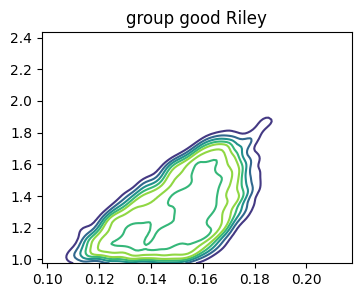

group=Miller, group_pool.shape=(8, 11, 120, 120), n_nan=0
DIAG q_group_Miller: shape=(120, 120), n_nan=0, n_inf=0, sum=1, min=5.888951910078307e-05, max=0.00017019580587178558


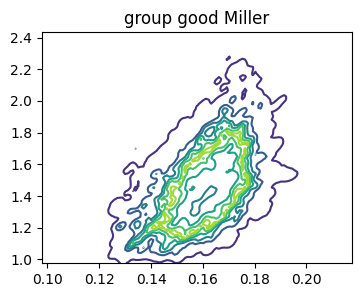

group=Vinciguerra, group_pool.shape=(8, 11, 120, 120), n_nan=0
DIAG q_group_Vinciguerra: shape=(120, 120), n_nan=0, n_inf=0, sum=1, min=5.180984534606866e-05, max=0.0002444189917543689


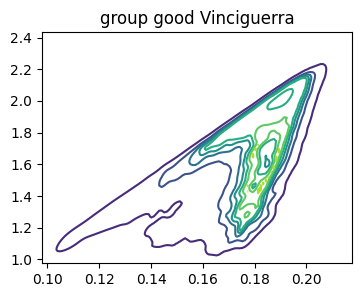

group=Kini, group_pool.shape=(8, 11, 120, 120), n_nan=0
DIAG q_group_Kini: shape=(120, 120), n_nan=0, n_inf=0, sum=1, min=5.9163824812995426e-05, max=0.00011421354072823904


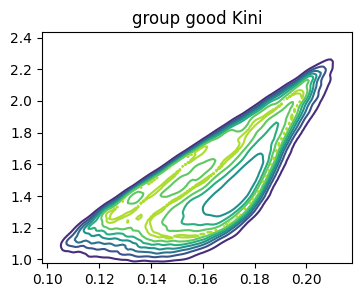

Group pooling diagnostics complete


In [44]:
# Diagnostics after group pooling
print('Running diagnostics on group_pool and group-level components')
for g in GROUP_MODELS:
    arr = group_pool[g]
    print(f'group={g}, group_pool.shape={arr.shape}, n_nan={np.isnan(arr).sum()}')
    # show the reference good component
    q = g_group_stack[GROUP_MODELS.index(g)]
    diag(f'q_group_{g}', q)
    plt.figure(figsize=(4,3))
    plt.contour(C_grid, M_grid, q.T, levels=6)
    plt.title(f'group good {g}')
    plt.show()
print('Group pooling diagnostics complete')


#### Final combination across groups, marginalize over sigma and rho, then convolve with systematics

In [45]:
Ndata = len(GROUP_MODELS)
NC = len(C_grid)
NM = len(M_grid)

# Systematic grid for convolution: ranges chosen from group spreads
sC = np.std([mu_group[g][0] for g in GROUP_MODELS])
sM = np.std([mu_group[g][1] for g in GROUP_MODELS])
sigma_C_sys_grid = np.linspace(0.0, 3.0 * sC + 1e-12, 6)
sigma_M_sys_grid = np.linspace(0.0, 3.0 * sM + 1e-12, 6)
r_sys_grid = np.linspace(-0.9, 0.9, 5)
# prior (simple)
prior_sigma_C = normalize_pdf_2d if False else (None)
# We'll build priors manually below
prior_sigma_C_sys = np.ones_like(sigma_C_sys_grid); prior_sigma_C_sys /= np.trapz(prior_sigma_C_sys, sigma_C_sys_grid)
prior_sigma_M_sys = np.ones_like(sigma_M_sys_grid); prior_sigma_M_sys /= np.trapz(prior_sigma_M_sys, sigma_M_sys_grid)
prior_r_sys = np.ones_like(r_sys_grid); prior_r_sys /= np.trapz(prior_r_sys, r_sys_grid)

# Rebuild b_dict and log_b for group-level models (use mu_group, Sigma_group)
b_group_dict = build_bad_likelihoods_2d(GROUP_MODELS, mu_group, Sigma_group, C_grid, M_grid, sigma_grid, alpha_grid, prior_alpha)
log_b_group_dict = {k: np.log(np.maximum(b_group_dict[k], floor)) for k in b_group_dict}

# Precompute log p arrays
log_p = np.log(p_grid + floor)[:, None, None]
log_1mp = np.log(1.0 - p_grid + floor)[:, None, None]

# Marginalize over sigma (model-level) and rho to get final posterior over (C,M)
P_C_given_sigma_rho = np.zeros((len(sigma_grid), len(rho_grid), NC, NM))
evidence_sigma_rho = np.zeros((len(sigma_grid), len(rho_grid)))

for s_index, sigma in enumerate(sigma_grid):
    # For this sigma, get group-level good and bad (good: log_g_group_stack, bad: log_b_group_dict)
    log_g_exp = log_g_group_stack[None, :, :, :]  # (1, Ng, nC, nM)
    log_b_exp = np.array([log_b_group_dict[g][s_index] for g in GROUP_MODELS])[None, :, :, :]

    log_mixture = logsumexp(np.stack([log_p[..., None] + log_g_exp, log_1mp[..., None] + log_b_exp]), axis=0)  # (len(p), Ng, nC, nM)

    for r_index, rho in enumerate(rho_grid):
        kappa = 1.0 / (1.0 + rho * (Ndata - 1))
        logL_p = kappa * np.sum(log_mixture, axis=1)  # sum over groups -> (len(p), nC, nM)
        maxlog = np.max(logL_p, axis=0, keepdims=True)
        L_p = np.exp(logL_p - maxlog)
        L = np.trapz(L_p * prior_p[:, None, None], p_grid, axis=0)
        L = normalize_pdf_2d(L, C_grid, M_grid)

        # Now marginalize over small group-level systematics sigma_C_sys, sigma_M_sys, r_sys by convolving L with multivariate kernels
        # We'll build P_C_given_sigma_rho as the already-marginalized group likelihood (systematic convolution later)
        Z = np.trapz(np.trapz(L, M_grid, axis=1), C_grid, axis=0)
        P_C_given_sigma_rho[s_index, r_index] = L / (Z + floor)
        evidence_sigma_rho[s_index, r_index] = Z

# Posterior over sigma and rho (model-level parameters)
posterior_sigma_rho = evidence_sigma_rho * prior_sigma[:, None] * prior_rho[None, :]
posterior_sigma_rho /= (np.trapz(np.trapz(posterior_sigma_rho, rho_grid, axis=1), sigma_grid) + floor)

# Final posterior before convolving systematics: average P(C,M) over posterior_sigma_rho
final_posterior_pre = np.trapz(np.trapz(P_C_given_sigma_rho * posterior_sigma_rho[:, :, None, None], rho_grid, axis=1), sigma_grid, axis=0)
final_posterior_pre = normalize_pdf_2d(final_posterior_pre, C_grid, M_grid)

print('Computed final posterior before systematic convolution')

Computed final posterior before systematic convolution


#### Systematic convolution over a correlated 2-D Gaussian kernel and final normalization

In [46]:
# Build convolution kernels for a small grid of (sigma_C_sys, sigma_M_sys, r_sys) and marginalize
def build_kernel_2d(sigma_C, sigma_M, r, C_grid, M_grid):
    # Build kernel centered at zero in grid coordinates
    CC_off, MM_off = np.meshgrid(C_grid - np.mean(C_grid), M_grid - np.mean(M_grid), indexing='ij')
    pts = np.vstack([CC_off.ravel(), MM_off.ravel()]).T
    cov = np.array([[sigma_C**2, r * sigma_C * sigma_M], [r * sigma_C * sigma_M, sigma_M**2]])
    rv = multivariate_normal(mean=[0.0, 0.0], cov=cov, allow_singular=True)
    k = rv.pdf(pts).reshape(CC_off.shape)
    k = k / (np.sum(k) * (C_grid[1] - C_grid[0]) * (M_grid[1] - M_grid[0]))
    return k

final_posterior = np.zeros_like(final_posterior_pre)
for sC in sigma_C_sys_grid:
    for sM in sigma_M_sys_grid:
        for r in r_sys_grid:
            prior = 1.0 / (len(sigma_C_sys_grid) * len(sigma_M_sys_grid) * len(r_sys_grid))
            if np.isclose(sC, 0.0) and np.isclose(sM, 0.0):
                conv = final_posterior_pre.copy()
            else:
                kernel = build_kernel_2d(sC, sM, r, C_grid, M_grid)
                conv = fftconvolve(final_posterior_pre, kernel, mode='same')
            final_posterior += prior * conv

final_posterior = normalize_pdf_2d(final_posterior, C_grid, M_grid)

print('Applied systematic convolution and normalized final posterior')


Applied systematic convolution and normalized final posterior


#### Marginals, sampling, and derived R

In [47]:
# Marginals
P_C = np.trapz(final_posterior, M_grid, axis=1)
P_M = np.trapz(final_posterior, C_grid, axis=0)
P_C /= (np.trapz(P_C, C_grid) + floor)
P_M /= (np.trapz(P_M, M_grid) + floor)

# Percentiles for joint posterior (use flattened sampling)
flat = final_posterior.ravel()
# Guard against NaNs or infinities produced upstream
flat_raw = flat.copy()
flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
_total = flat.sum()
# Diagnostics
n_nan = np.isnan(flat_raw).sum()
n_inf = np.isinf(flat_raw).sum()
_min = np.nanmin(flat_raw) if flat_raw.size and np.any(np.isfinite(flat_raw)) else np.nan
_max = np.nanmax(flat_raw) if flat_raw.size and np.any(np.isfinite(flat_raw)) else np.nan
print(f'final_posterior: shape={final_posterior.shape}, sum(raw)={np.sum(flat_raw):.6g}, sum(clean)={_total:.6g}, n_nan={n_nan}, n_inf={n_inf}, min={_min}, max={_max}')

if _total <= 0 or not np.isfinite(_total):
    import warnings
    warnings.warn('final_posterior has no finite positive mass; falling back to uniform sampling over grid for diagnostics')
    flat = np.ones_like(flat)
    flat /= np.sum(flat)
else:
    flat /= _total

indices = np.arange(flat.size)
# Draw samples (use a smaller draw count when fallback triggered to speed debugging)
n_draw = 20000
try:
    draws = np.random.choice(indices, size=n_draw, replace=True, p=flat)
except Exception as e:
    # If random.choice still fails, fall back to simple uniform draws
    import warnings
    warnings.warn(f'Sampling with provided probabilities failed: {e}; using uniform draws')
    draws = np.random.choice(indices, size=n_draw, replace=True)

C_coords = CC.ravel()[draws]
M_coords = MM.ravel()[draws]
R_coords = 1.476625 * M_coords / C_coords

samples_CM = np.vstack([C_coords, M_coords]).T
samples_MR = np.vstack([M_coords, R_coords]).T

print('Drew samples from joint posterior; produced derived R samples')

final_posterior: shape=(120, 120), sum(raw)=1, sum(clean)=1, n_nan=0, n_inf=0, min=6.944444444444444e-05, max=6.944444444444444e-05
Drew samples from joint posterior; produced derived R samples


#### Diagnostics and plots

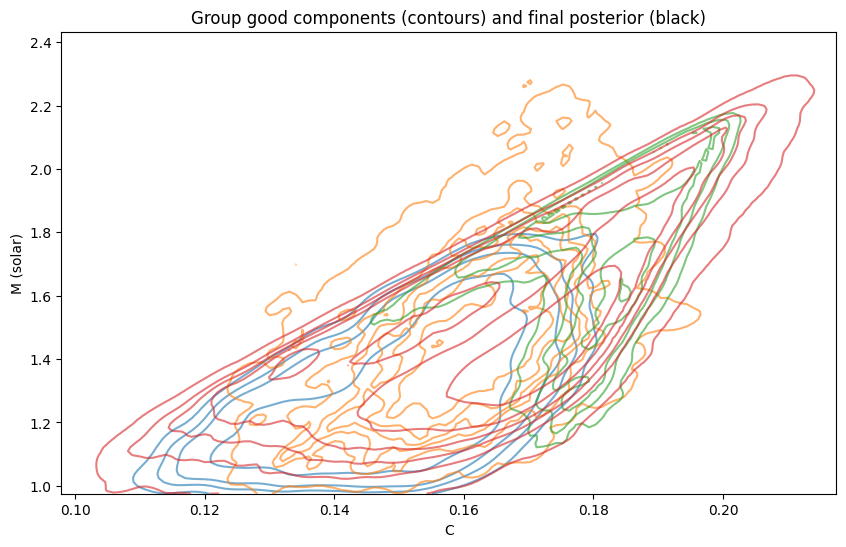

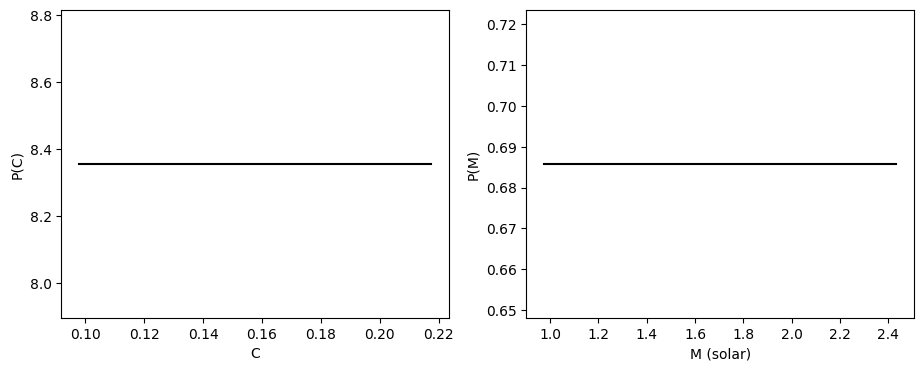

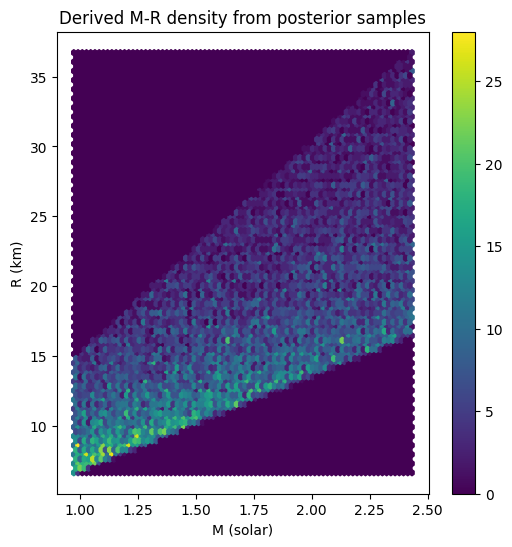

Diagnostics: produced group contours, marginals, and derived M-R density


In [48]:
# Plot group-level good components and final posterior contours
plt.figure(figsize=(10, 6))
for i, g in enumerate(GROUP_MODELS):
    plt.contour(C_grid, M_grid, g_group_stack[i].T, levels=3, alpha=0.6, colors=[plt.rcParams['axes.prop_cycle'].by_key()['color'][i]])
plt.contour(C_grid, M_grid, final_posterior.T, levels=6, colors='k', linewidths=1.2)
plt.xlabel('C')
plt.ylabel('M (solar)')
plt.title('Group good components (contours) and final posterior (black)')
plt.show()

# Marginal plots
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(C_grid, P_C, color='black')
ax[0].set_xlabel('C')
ax[0].set_ylabel('P(C)')
ax[1].plot(M_grid, P_M, color='black')
ax[1].set_xlabel('M (solar)')
ax[1].set_ylabel('P(M)')
plt.show()

# Derived M-R contours from samples
plt.figure(figsize=(6, 6))
hb = plt.hexbin(M_coords, R_coords, gridsize=80, cmap='viridis')
plt.xlabel('M (solar)')
plt.ylabel('R (km)')
plt.title('Derived M-R density from posterior samples')
plt.colorbar(hb)
plt.show()

print('Diagnostics: produced group contours, marginals, and derived M-R density')
